In [107]:
# Первая часть - исследование

In [108]:
## Описание задачи 
### В данной работе предстоит моделировать отток клиентов телеком компании.
### Целевым признаком является столбец Church (Отток) в данных.
### Эта задача очень важна на практике и алгоритмы для ее решения используются в реальных 
### телеком компаниях, ведь если мы знаем, что клиент собирается уйти от нас, 
### то мы попытаться удержать его, предложив какие-то бонусы. 

In [109]:
import kagglehub

path = kagglehub.competition_download('advanced-dls-spring-2021')
kagglehub.whoami()

Kaggle credentials successfully validated.


{'username': 'seradrug'}

In [110]:
## Импорты

In [111]:
import os 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression 
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.base import clone

In [112]:
## Загружаю данные

In [113]:
df = pd.read_csv(os.path.join(path, "train.csv"))
X_test = pd.read_csv(os.path.join(path, "test.csv"))

In [166]:
df.head()

,ClientPeriod,MonthlySpending,TotalSpent,Sex,IsSeniorCitizen,HasPartner,HasChild,HasPhoneService,HasMultiplePhoneNumbers,HasInternetService,HasOnlineSecurityService,HasOnlineBackup,HasDeviceProtection,HasTechSupportAccess,HasOnlineTV,HasMovieSubscription,HasContractPhone,IsBillingPaperless,PaymentMethod,Churn
0,55,19.50,1026.35,Male,0,Yes,Yes,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,0
1,72,25.85,1872.20,Male,0,Yes,No,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),0
2,1,75.90,75.90,Male,0,No,No,Yes,No,Fiber optic,No,No,No,Yes,No,No,Month-to-month,Yes,Electronic check,1
3,32,79.30,2570.00,Female,1,Yes,No,Yes,Yes,Fiber optic,No,No,Yes,No,No,No,Month-to-month,No,Mailed check,0
4,60,115.25,6758.45,Female,0,Yes,Yes,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,No,Credit card (automatic),0


In [114]:
# Предобработка

In [115]:
df = df.replace(" ", np.nan)

In [116]:
df["TotalSpent"] = df["TotalSpent"].astype(float)

In [117]:
filled_df = df.copy()

In [118]:
family_col = [
    "HasPartner",
    "HasChild",
]

In [119]:
movie_col = [
    "HasOnlineTV",
    "HasMovieSubscription",
]

In [120]:
tech_col = [
    "HasOnlineSecurityService",
    "HasOnlineBackup",
    "HasDeviceProtection",
    "HasTechSupportAccess",
]

In [121]:
cat_col = [
    "HasMultiplePhoneNumbers",
    "HasOnlineSecurityService",
    "HasOnlineBackup",
    "HasDeviceProtection",
    "HasTechSupportAccess",
    "HasOnlineTV",
    "HasMovieSubscription",
    "HasInternetService",
    "HasContractPhone",
    "PaymentMethod",
]

In [122]:
num_col = [
    "ClientPeriod",
    "MonthlySpending",
    "TotalSpent",
]

In [123]:
## Заполняем все NaN на среднее значение в столбце TotalSpent

In [124]:
filled_df["TotalSpent"] = filled_df["TotalSpent"].fillna(filled_df["TotalSpent"].mean())

In [125]:
## Бинарная категоризация
filled_df["Sex"] = filled_df["Sex"].map({"Male": 1, "Female": 0}).astype(int)
yes_no_columns = [ 
    "HasPartner",
    "HasChild",
    "HasPhoneService",
    "IsBillingPaperless"
]

filled_df[yes_no_columns] = filled_df[yes_no_columns].replace({"Yes": 1, "No": 0}).astype(int)

In [126]:
## Добавляю новые фичи

In [127]:
filled_df[family_col] = filled_df[family_col].astype(int)

In [128]:
filled_df["Family"] = filled_df[family_col].sum(axis=1)

In [129]:
filled_df["Movie_service"] = filled_df[movie_col].eq("Yes").sum(axis=1)

In [130]:
filled_df["Tech_Service"] = filled_df[tech_col].eq("Yes").sum(axis=1)

In [131]:
filled_df = filled_df.drop(columns=family_col)

In [132]:
#filled_df.info(10)

In [133]:
X_train = filled_df.drop(columns="Churn")
y_train = filled_df["Churn"]

In [134]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

In [135]:
preprocessor = ColumnTransformer(
    [("cat", OneHotEncoder(sparse_output=False, drop="if_binary"), cat_col),
      ("num", StandardScaler(), num_col)], remainder="passthrough")

preprocessor.set_output(transform="pandas")

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``.

In [136]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

In [137]:
model = Pipeline(
    [('preprocessor', preprocessor), ("classifier", LogisticRegression(max_iter=1000))
    ])
model.fit(X_tr, y_tr)

models = {
    "LogReg": LogisticRegression(C=100, l1_ratio=0.2, max_iter=1000, solver='saga'),
    "GradBoost": GradientBoostingClassifier(n_estimators=150, learning_rate=0.02,
                                            max_depth=2, random_state=42),
    "CatBoost": CatBoostClassifier(iterations=250, loss_function="CrossEntropy", 
                                   learning_rate=0.02, depth=3, l2_leaf_reg=3,
                                   verbose=0, random_seed=42),
    "LGBM": LGBMClassifier(n_estimators=250,
        num_leaves=5,
        max_depth=2,
        min_child_samples=2,
        min_gain_to_split=0.01,
        reg_alpha=10,
        reg_lambda=5,
        ),
    "XGB": XGBClassifier(n_estimators=256,
      learning_rate=0.03,
      max_depth=3,

      min_child_weight=5,
      gamma=0.05,

      subsample=0.85,
      colsample_bytree=0.85,

      reg_alpha=0.1,
      reg_lambda=5,

      objective="binary:logistic",
      eval_metric="auc",

      random_state=42,
      n_jobs=-1),
}

In [138]:
# Выбираю модель 

In [139]:
res_mean = {}
res_std = {}

In [140]:
for name, clf in models.items():
    pipe = Pipeline(
        [('prepocessor', preprocessor), ("classifier", clf)])
    scores = cross_val_score(
        pipe,
        X_tr,
        y_tr,
        cv=cv,
        scoring="roc_auc"
    )
    res_mean[name] = scores.mean()
    res_std[name] = scores.std()
    print(
        name,
        scores.mean(),
        scores.std()
    )

LogReg 0.841507374291832 0.012448155816612837
GradBoost 0.84099710378404 0.010747841525889512
CatBoost 0.8445186410293305 0.0103426447752473
[LightGBM] [Warning] min_gain_to_split is set=0.01, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.01
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] min_gain_to_split is set=0.01, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.01
[LightGBM] [Info] Number of positive: 885, number of negative: 2495
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000757 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 665
[LightGBM] [Info] Number of data points in the train set: 3380, number of used features: 41
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.261834 -> initscore=-1.036456
[LightGBM] [Info] Start training from score -1.036456
[LightGBM] [Warning] No further splits

In [141]:
best_model_name = max(res_mean, key=res_mean.get)

print(f"Название лучшей модели: {best_model_name}", f"CV скор: res[best_model]", sep="\n")

Название лучшей модели: CatBoost
CV скор: res[best_model]


In [153]:
best_clf = models[best_model_name]

best_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', best_clf)
])

best_pipe.fit(X_tr, y_tr)

val_pred = best_pipe.predict_proba(X_val)[:, 1]

val_score = roc_auc_score(y_val, val_pred)

logreg_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', models["LogReg"])
])

logreg_pipe.fit(X_tr, y_tr)

val_pred_reg = logreg_pipe.predict_proba(X_val)[:, 1]

val_score_reg = roc_auc_score(
    y_val,
    val_pred_reg
)
print("LogReg: Hold-out ROC-AUC:", val_score_reg)
print("LogReg: CV ROC-AUC:", res_mean["LogReg"], res_std["LogReg"])
print("CatBoost: Hold-out ROC-AUC:", val_score)
print("CatBoost: CV ROC-AUC:", res_mean[best_model_name], res_std[best_model_name])

LogReg: Hold-out ROC-AUC: 0.8547903360177729
LogReg: CV ROC-AUC: 0.841507374291832 0.012448155816612837
CatBoost: Hold-out ROC-AUC: 0.8555540127742294
CatBoost: CV ROC-AUC: 0.8445186410293305 0.0103426447752473


In [154]:
## Baseline (logregression: score - 0.844, randomforest: score - 0.823) 
## CatBoost: score - 0.848

In [155]:
filled_df_eda = X_train.copy()
filled_df_eda["Churn"] = y_train

In [156]:
eda_preprocessor = ColumnTransformer(
    [
        ("cat", OneHotEncoder(sparse_output=False, drop="if_binary"), cat_col),
        ("num", StandardScaler(), num_col)
    ],
    remainder="passthrough"
)

eda_preprocessor.set_output(transform="pandas")

filled_df_encoded = eda_preprocessor.fit_transform(filled_df_eda)

In [157]:
corr = filled_df_encoded.corr()

target = corr[["remainder__Churn"]].sort_values(
    by="remainder__Churn",
    ascending=False
)

target

,remainder__Churn
remainder__Churn,1.000000
cat__HasContractPhone_Month-to-month,0.403429
cat__HasOnlineSecurityService_No,0.352716
cat__HasTechSupportAccess_No,0.337312
cat__HasInternetService_Fiber optic,0.300399
cat__PaymentMethod_Electronic check,0.296715
cat__HasOnlineBackup_No,0.272217
cat__HasDeviceProtection_No,0.254124
remainder__IsBillingPaperless,0.194040
num__MonthlySpending,0.184769


In [158]:
## Хитмапа - корреляция таргета с каждым признаком

In [160]:
## HeatMap -- проверяю корреляцию м/у каждым признаком 

<Axes: >

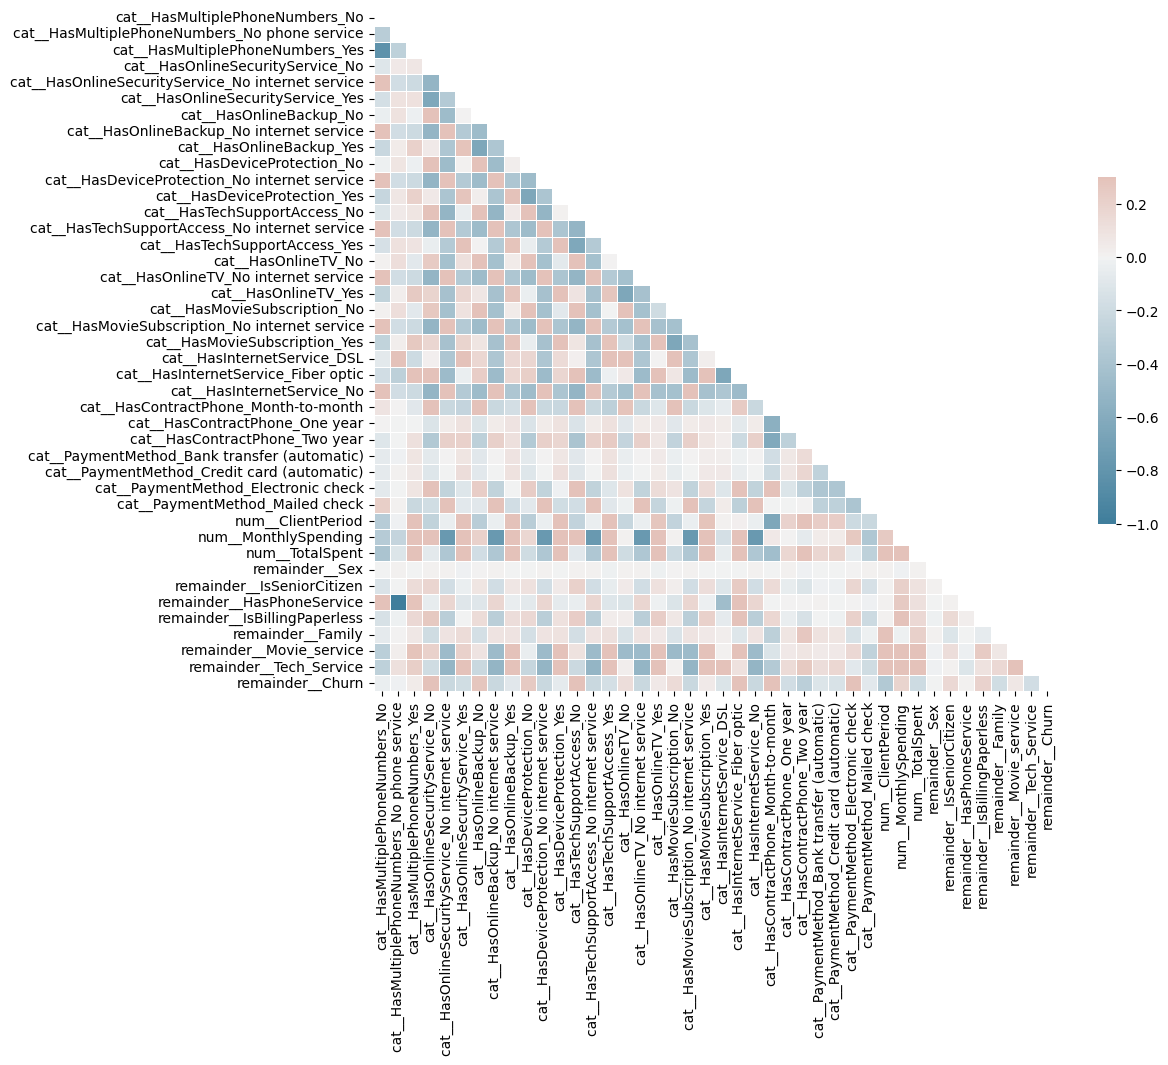

In [161]:
mask = np.triu(np.ones_like(corr, dtype=bool))
f, ax = plt.subplots(figsize=(11,9))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=.3, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})

In [162]:
feature_name = best_pipe.named_steps["preprocessor"].get_feature_names_out()
clf = best_pipe.named_steps["classifier"]

feature_importance = (
    pd.DataFrame({
        "feature": feature_name,
        "importance": clf.feature_importances_
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

top7 = feature_importance.head(7)
top7

,feature,importance
0,cat__HasContractPhone_Month-to-month,21.623009
1,num__ClientPeriod,16.144115
2,cat__HasInternetService_Fiber optic,9.842047
3,cat__HasContractPhone_Two year,8.536780
4,cat__HasOnlineSecurityService_No,7.254933
5,num__TotalSpent,6.609706
6,cat__HasTechSupportAccess_No,5.396588


In [170]:
def prepare_test_data(test_df, total_spent_mean):
    result = test_df.copy()

    result = result.replace(" ", np.nan)
    result["TotalSpent"] = result["TotalSpent"].astype(float)
    result["TotalSpent"] = result["TotalSpent"].fillna(total_spent_mean)

    result["Sex"] = result["Sex"].map({"Male": 1, "Female": 0}).astype(int)

    yes_no_columns = [
        "HasPartner",
        "HasChild",
        "HasPhoneService",
        "IsBillingPaperless",
    ]
    result[yes_no_columns] = (
        result[yes_no_columns]
        .replace({"Yes": 1, "No": 0})
        .astype(int)
    )

    result["Family"] = result[family_col].sum(axis=1)
    result["Movie_service"] = result[movie_col].eq("Yes").sum(axis=1)
    result["Tech_Service"] = result[tech_col].eq("Yes").sum(axis=1)

    result = result.drop(columns=family_col)

    return result

total_spent_mean = df["TotalSpent"].mean()
X_test_ready = prepare_test_data(X_test, total_spent_mean)

print("Train shape:", X_train.shape)
print("Test shape:", X_test_ready.shape)
print("Одинаковый набор признаков:",
      list(X_train.columns) == list(X_test_ready.columns))


Train shape: (5282, 20)
Test shape: (1761, 20)
Одинаковый набор признаков: True


In [173]:
final_pipe = clone(best_pipe)
final_pipe.fit(X_train, y_train)

test_pred = final_pipe.predict_proba(X_test_ready)[:, 1]

In [174]:
print(os.listdir(path))

['train.csv', 'test.csv', 'submission.csv']


In [175]:
sample_submission = pd.read_csv(
    os.path.join(path, "submission.csv")
)

sample_submission.head()

,Id,Churn
0,0,0.5
1,1,0.5
2,2,0.5
3,3,0.5
4,4,0.5


In [176]:
submission = sample_submission.copy()

submission["Churn"] = test_pred

submission.to_csv(
    "submission.csv",
    index=False
)

submission.head()

,Id,Churn
0,0,0.053236
1,1,0.598354
2,2,0.643026
3,3,0.020932
4,4,0.010865
